========== Initial diagnostics ==========
R0_cm                = 3.085678e+18
box_length_cm        = 3.085678e+15
box_volume_cm3       = 2.937999e+46
rho_g                = 4.515785e-14 g/cm^3
simulated rho_d      = 2.257892e-13 g/cm^3
c_s                  = 5.937634e+04 cm/s
Omega_K              = 6.721041e-12 1/s
n_superparticles     = 10000
initial mean m_dust  = 3.215059e-08 g
initial mean radius  = 1.270903e-03 cm
initial mean Stokes  = 3.185681e-06
initial total m_sp   = 6.633685e+33 g
========== Final diagnostics ==========
final mean m_dust    = 4.805166e-01 g
final mean radius    = 2.645314e-01 cm
final mean Stokes    = 3.315398e-03
final total m_sp     = 6.633685e+33 g
total collisions     = 908633
  sticking           = 369238
  compaction         = 428811
  fragmentation      = 110584
Wall-clock runtime = 0.89 s = 0.01 min
========== Snapshot Summary ==========
Number of snapshots  = 11
First snapshot       = snapshot_000.npz
Last snapshot        = snapshot_010.npz
Initial 

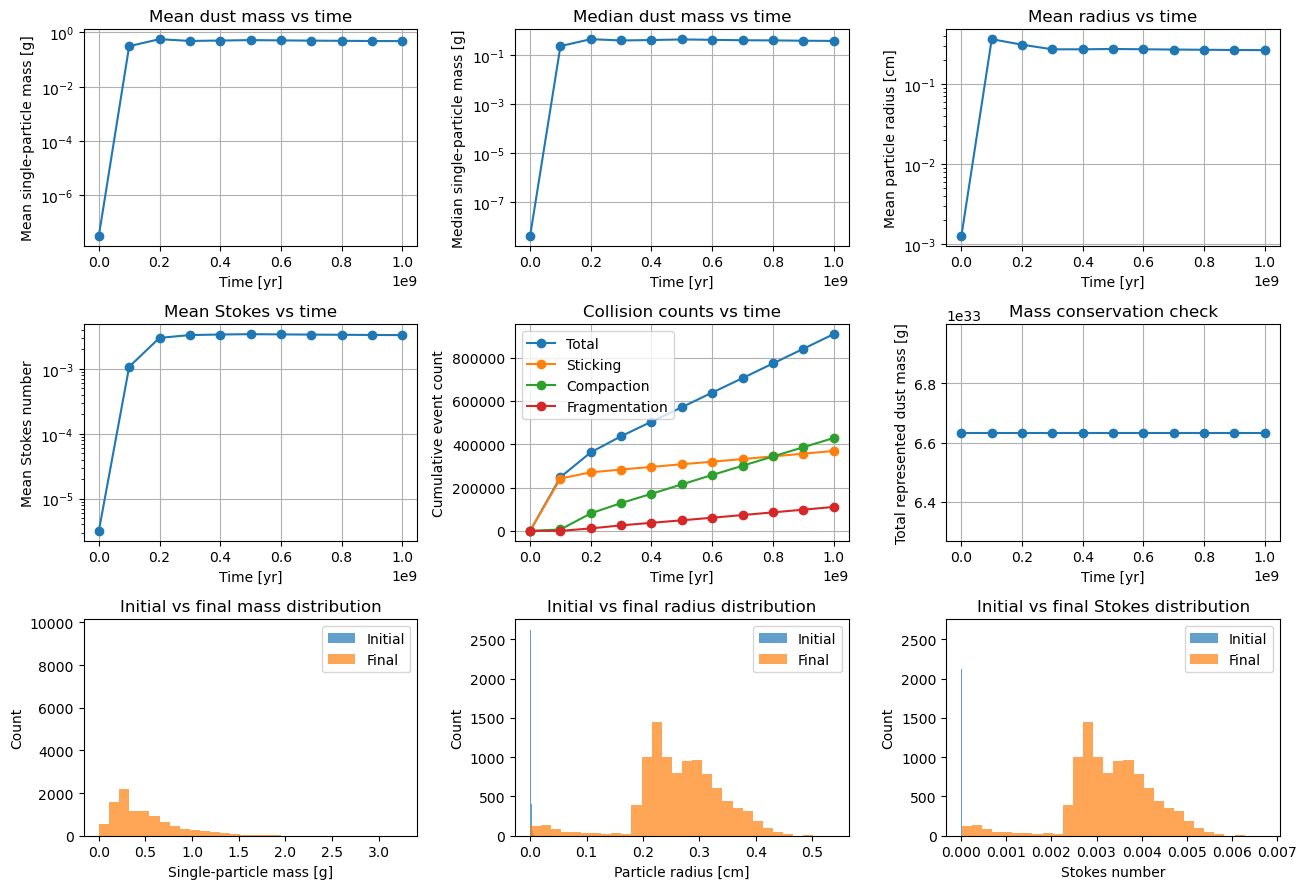

In [17]:
import os
import math
import shutil
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical constants (CGS, pure float)
# ============================================================
G_CGS = 6.67430e-8              # cm^3 g^-1 s^-2
KB_CGS = 1.380649e-16           # erg K^-1 = g cm^2 s^-2 K^-1
MH_CGS = 1.6735575e-24          # g
PI = math.pi

PC_TO_CM = 3.08567758e18        # cm
MSUN_TO_G = 1.98847e33          # g
YR_TO_S = 3.15576e7             # s


# ============================================================
# Disk parameters
# ============================================================
@dataclass(frozen=True)
class DiskParams:
    """
    Minimal AGN disk model in pure CGS.

    T(R)     = T0 * (R / 1 pc)^(-q)
    Sigma(R) = Sigma0 * (R / 1 pc)^(-p)
    """
    MBH_g: float = 1.0e7 * MSUN_TO_G #
    T0_K: float = 100.0 #
    q: float = 0.5

    Sigma0_g_cm2: float = 1.0e3
    p: float = 1.0

    mu: float = 2.34
    rho_s_g_cm3: float = 1.0          # initial/internal grain density
    alpha: float = 1.0e-3
    f_dg_avg: float = 0.5             # dust-to-gas mass ratio in the local box


# ============================================================
# Simulation parameters
# ============================================================
@dataclass(frozen=True)
class SimulationParams:
    """
    Fixed-swarm representative-particle Monte Carlo.
    Each swarm keeps constant total mass m_sp.
    The grain mass m_dust inside the swarm evolves.
    """

    R0_pc: float = 1.0
    box_length_pc: float = 1.0e-3 #

    n_superparticles: int = 10000

    initial_swarm_mass_g: float = 6.633685e29 #

    initial_radius_cm: float = 1.0e-3 #
    initial_radius_logscatter_dex: float = 0.3
    min_radius_cm: float = 1.0e-5

    t_end_yr: float = 1.0e9 #
    dt_yr: float = 1.0e6
    snapshot_every_yr: float = 1.0e8

    v_stick_cm_s: float = 50 #
    v_frag_cm_s: float = 1.0e2 #

    compaction_factor: float = 1.2 #
    fragment_factor: float = 0.5 #
    max_internal_density_g_cm3: float = 5.0

    output_dir: str = "snapshots"
    seed: int = 0

    @property
    def R0_cm(self) -> float:
        return self.R0_pc * PC_TO_CM

    @property
    def box_length_cm(self) -> float:
        return self.box_length_pc * PC_TO_CM

    @property
    def box_volume_cm3(self) -> float:
        return self.box_length_cm ** 3

    @property
    def t_end_s(self) -> float:
        return self.t_end_yr * YR_TO_S

    @property
    def dt_s(self) -> float:
        return self.dt_yr * YR_TO_S

    @property
    def snapshot_times_s(self):
        if self.snapshot_every_yr <= 0:
            raise ValueError("snapshot_every_yr must be positive.")
        n_snaps = max(1, int(self.t_end_yr / self.snapshot_every_yr))
        return tuple(i * self.snapshot_every_yr * YR_TO_S for i in range(1, n_snaps + 1))


# ============================================================
# Disk background quantities
# ============================================================
def temperature(R_cm: float, params: DiskParams) -> float:
    R_pc = R_cm / PC_TO_CM
    return params.T0_K * (R_pc ** (-params.q))


def surface_density(R_cm: float, params: DiskParams) -> float:
    R_pc = R_cm / PC_TO_CM
    return params.Sigma0_g_cm2 * (R_pc ** (-params.p))


def omega_k(R_cm: float, params: DiskParams) -> float:
    return math.sqrt(G_CGS * params.MBH_g / (R_cm ** 3))


def sound_speed(R_cm: float, params: DiskParams) -> float:
    T = temperature(R_cm, params)
    return math.sqrt(KB_CGS * T / (params.mu * MH_CGS))


def scale_height(R_cm: float, params: DiskParams) -> float:
    return sound_speed(R_cm, params) / omega_k(R_cm, params)


def midplane_gas_density(R_cm: float, params: DiskParams) -> float:
    sigma = surface_density(R_cm, params)
    H = scale_height(R_cm, params)
    return sigma / (math.sqrt(2.0 * PI) * H)


def midplane_dust_density(R_cm: float, params: DiskParams) -> float:
    return params.f_dg_avg * midplane_gas_density(R_cm, params)


# ============================================================
# Particle property helpers
# ============================================================
def mass_from_radius(a_cm, rho_int_g_cm3):
    return (4.0 / 3.0) * PI * (a_cm ** 3) * rho_int_g_cm3


def radius_from_mass(m_g, rho_int_g_cm3):
    return ((3.0 * m_g) / (4.0 * PI * rho_int_g_cm3)) ** (1.0 / 3.0)


def stopping_time(a_cm, rho_int_g_cm3, R_cm: float, params: DiskParams):
    rho_g = midplane_gas_density(R_cm, params)
    c_s = sound_speed(R_cm, params)
    return (rho_int_g_cm3 * a_cm) / (rho_g * c_s)


def stokes_number(t_stop_s, R_cm: float, params: DiskParams):
    return t_stop_s * omega_k(R_cm, params)


def update_derived_properties(data, R_cm: float, disk_params: DiskParams):
    """
    Fixed swarm-mass semantics:
        m_sp is constant for each swarm
        N_sp = m_sp / m_dust
    """
    rho_g = midplane_gas_density(R_cm, disk_params)
    c_s = sound_speed(R_cm, disk_params)
    om_k = omega_k(R_cm, disk_params)

    data["r_sp"] = radius_from_mass(data["m_dust"], data["rho_sp"])
    data["N_sp"] = data["m_sp"] / data["m_dust"]
    data["ts"] = (data["rho_sp"] * data["r_sp"]) / (rho_g * c_s)
    data["St"] = data["ts"] * om_k

    if np.any(~np.isfinite(data["St"])) or np.any(data["St"] <= 0.0):
        raise ValueError("Non-finite or non-positive Stokes number detected.")

    if np.any(~np.isfinite(data["N_sp"])) or np.any(data["N_sp"] <= 0.0):
        raise ValueError("Non-finite or non-positive N_sp detected.")

    return data


# ============================================================
# Relative velocities and collision kernel
# ============================================================
def brownian_velocity(m1, m2, R_cm: float, params: DiskParams):
    T = temperature(R_cm, params)
    return np.sqrt((8.0 * KB_CGS * T / PI) * (1.0 / m1 + 1.0 / m2))


def turbulent_velocity(St1, St2, R_cm: float, params: DiskParams):
    c_s = sound_speed(R_cm, params)
    return np.sqrt(params.alpha) * c_s * np.sqrt(np.abs(St1 - St2))


def radial_velocity(St, R_cm: float, params: DiskParams):
    v_k = np.sqrt(G_CGS * params.MBH_g / R_cm)
    eta = (sound_speed(R_cm, params) ** 2) / (v_k ** 2)
    return -2.0 * eta * v_k * St / (1.0 + St ** 2)


def relative_velocity_vec(m1, m2, St1, St2, R_cm: float, params: DiskParams):
    v_brown = brownian_velocity(m1, m2, R_cm, params)
    v_turb = turbulent_velocity(St1, St2, R_cm, params)
    v_rad = np.abs(radial_velocity(St1, R_cm, params) - radial_velocity(St2, R_cm, params))
    return np.sqrt(v_brown ** 2 + v_turb ** 2 + v_rad ** 2)


def collision_kernel_vec(a1, a2, v_rel):
    sigma = PI * (a1 + a2) ** 2
    return sigma * v_rel


# ============================================================
# Initialization
# ============================================================
def initialize_superparticles(sim_params: SimulationParams,
                              disk_params: DiskParams,
                              rng=None):
    if rng is None:
        rng = np.random.default_rng(sim_params.seed)

    n = sim_params.n_superparticles
    if n < 2:
        raise ValueError("n_superparticles must be at least 2.")

    dtype = [
        ("id", "i4"),
        ("r_sp", "f8"),
        ("rho_sp", "f8"),
        ("m_dust", "f8"),
        ("N_sp", "f8"),
        ("m_sp", "f8"),
        ("ts", "f8"),
        ("St", "f8"),
    ]
    data = np.zeros(n, dtype=dtype)
    data["id"] = np.arange(1, n + 1)

    # Initial internal density
    data["rho_sp"] = disk_params.rho_s_g_cm3

    # Radius distribution
    r0 = sim_params.initial_radius_cm
    if sim_params.initial_radius_logscatter_dex > 0.0:
        ln_sigma = sim_params.initial_radius_logscatter_dex * np.log(10.0)
        data["r_sp"] = r0 * np.exp(rng.normal(0.0, ln_sigma, n))
    else:
        data["r_sp"] = r0

    # Initial single-particle masses
    data["m_dust"] = mass_from_radius(data["r_sp"], data["rho_sp"])

    data["m_sp"] = sim_params.initial_swarm_mass_g

    data = update_derived_properties(data, sim_params.R0_cm, disk_params)
    return data


# ============================================================
# Collision outcomes
# ============================================================
def classify_collision_array(v_rel, sim_params: SimulationParams):
    """
    0 = sticking
    1 = compaction
    2 = fragmentation
    """
    out = np.empty_like(v_rel, dtype=np.int8)
    out[v_rel < sim_params.v_stick_cm_s] = 0
    mid = (v_rel >= sim_params.v_stick_cm_s) & (v_rel < sim_params.v_frag_cm_s)
    out[mid] = 1
    out[v_rel >= sim_params.v_frag_cm_s] = 2
    return out


def resolve_collisions_vectorized(data,
                                  dt_s: float,
                                  box_volume_cm3: float,
                                  R_cm: float,
                                  sim_params: SimulationParams,
                                  disk_params: DiskParams,
                                  rng=None):
    """
    Fixed-number representative-particle update.

    For each random pair:
      - randomly choose one target swarm and one partner swarm
      - collision probability for target is:
            p = n_partner * K_ij * dt
      - if collision occurs:
            sticking      -> target m_dust increases
            compaction    -> target rho_sp increases
            fragmentation -> target m_dust decreases

    Swarm total mass m_sp stays fixed.
    """
    if rng is None:
        rng = np.random.default_rng(sim_params.seed)

    n = len(data)
    if n < 2:
        return data, {"total": 0, "sticking": 0, "compaction": 0, "fragmentation": 0}, 0.0

    indices = np.arange(n)
    rng.shuffle(indices)

    n_pairs = n // 2
    idx1 = indices[:n_pairs]
    idx2 = indices[n_pairs:2 * n_pairs]

    choose_first_as_target = rng.random(n_pairs) < 0.5
    tgt_idx = np.where(choose_first_as_target, idx1, idx2)
    prt_idx = np.where(choose_first_as_target, idx2, idx1)

    m_t = data["m_dust"][tgt_idx]
    m_p = data["m_dust"][prt_idx]
    St_t = data["St"][tgt_idx]
    St_p = data["St"][prt_idx]
    a_t = data["r_sp"][tgt_idx]
    a_p = data["r_sp"][prt_idx]

    v_rel = relative_velocity_vec(m_t, m_p, St_t, St_p, R_cm, disk_params)
    K_ij = collision_kernel_vec(a_t, a_p, v_rel)

    # partner number density in the local box
    n_partner = data["N_sp"][prt_idx] / box_volume_cm3

    raw_prob = n_partner * K_ij * dt_s
    max_raw_prob = float(np.max(raw_prob)) if len(raw_prob) else 0.0
    prob = np.clip(raw_prob, 0.0, 1.0)

    collided = rng.random(n_pairs) < prob
    n_coll = int(np.sum(collided))

    stats = {"total": n_coll, "sticking": 0, "compaction": 0, "fragmentation": 0}
    if n_coll == 0:
        return data, stats, max_raw_prob

    ctgt = tgt_idx[collided]
    cprt = prt_idx[collided]
    cv = v_rel[collided]

    outcome = classify_collision_array(cv, sim_params)

    # ------------------------------
    # sticking
    # ------------------------------
    mask = (outcome == 0)
    if np.any(mask):
        it = ctgt[mask]
        ip = cprt[mask]

        m_old_t = data["m_dust"][it].copy()
        m_old_p = data["m_dust"][ip]
        rho_old_t = data["rho_sp"][it].copy()
        rho_old_p = data["rho_sp"][ip]

        new_m = m_old_t + m_old_p
        new_rho = (m_old_t * rho_old_t + m_old_p * rho_old_p) / new_m

        data["m_dust"][it] = new_m
        data["rho_sp"][it] = np.minimum(new_rho, sim_params.max_internal_density_g_cm3)

        stats["sticking"] = int(np.sum(mask))

    # ------------------------------
    # compaction
    # ------------------------------
    mask = (outcome == 1)
    if np.any(mask):
        it = ctgt[mask]
        data["rho_sp"][it] *= sim_params.compaction_factor
        data["rho_sp"][it] = np.minimum(data["rho_sp"][it], sim_params.max_internal_density_g_cm3)
        stats["compaction"] = int(np.sum(mask))

    # ------------------------------
    # fragmentation
    # ------------------------------
    mask = (outcome == 2)
    if np.any(mask):
        it = ctgt[mask]
        data["m_dust"][it] *= sim_params.fragment_factor

        m_floor = mass_from_radius(sim_params.min_radius_cm, disk_params.rho_s_g_cm3)
        data["m_dust"][it] = np.maximum(data["m_dust"][it], m_floor)

        stats["fragmentation"] = int(np.sum(mask))

    return data, stats, max_raw_prob


# ============================================================
# Snapshot I/O
# ============================================================
def snapshot_from_superparticles(data, t_s: float, cumulative_stats: dict):
    return {
        "time": float(t_s),
        "masses": data["m_dust"].copy(),
        "radii": data["r_sp"].copy(),
        "densities": data["rho_sp"].copy(),
        "numbers": data["N_sp"].copy(),
        "swarm_masses": data["m_sp"].copy(),
        "stokes": data["St"].copy(),
        "stopping_times": data["ts"].copy(),
        "coll_total": int(cumulative_stats["total"]),
        "coll_sticking": int(cumulative_stats["sticking"]),
        "coll_compaction": int(cumulative_stats["compaction"]),
        "coll_fragmentation": int(cumulative_stats["fragmentation"]),
    }


def save_snapshot(snapshot, output_path: str):
    np.savez(
        output_path,
        time=snapshot["time"],
        masses=snapshot["masses"],
        radii=snapshot["radii"],
        densities=snapshot["densities"],
        numbers=snapshot["numbers"],
        swarm_masses=snapshot["swarm_masses"],
        stokes=snapshot["stokes"],
        stopping_times=snapshot["stopping_times"],
        coll_total=snapshot["coll_total"],
        coll_sticking=snapshot["coll_sticking"],
        coll_compaction=snapshot["coll_compaction"],
        coll_fragmentation=snapshot["coll_fragmentation"],
    )


def read_snapshot(path: str):
    with np.load(path, allow_pickle=True) as data:
        return {
            "time": float(data["time"]),
            "masses": np.array(data["masses"], dtype=float),
            "radii": np.array(data["radii"], dtype=float),
            "densities": np.array(data["densities"], dtype=float),
            "numbers": np.array(data["numbers"], dtype=float),
            "swarm_masses": np.array(data["swarm_masses"], dtype=float),
            "stokes": np.array(data["stokes"], dtype=float),
            "stopping_times": np.array(data["stopping_times"], dtype=float),
            "coll_total": int(data["coll_total"]),
            "coll_sticking": int(data["coll_sticking"]),
            "coll_compaction": int(data["coll_compaction"]),
            "coll_fragmentation": int(data["coll_fragmentation"]),
        }


# ============================================================
# Main Monte Carlo driver
# ============================================================
def run_monte_carlo_vectorized(disk_params: DiskParams,
                               sim_params: SimulationParams,
                               output_dir=None,
                               rng=None):
    if rng is None:
        rng = np.random.default_rng(sim_params.seed)

    if output_dir is None:
        output_dir = sim_params.output_dir

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    R_cm = sim_params.R0_cm
    dt_s = sim_params.dt_s
    t_end_s = sim_params.t_end_s
    snapshot_times_s = list(sim_params.snapshot_times_s)

    data = initialize_superparticles(sim_params, disk_params, rng=rng)

    rho_g = midplane_gas_density(R_cm, disk_params)


    simulated_total_dust_mass = np.sum(data["m_sp"])
    rho_d = simulated_total_dust_mass / sim_params.box_volume_cm3

    c_s = sound_speed(R_cm, disk_params)
    om = omega_k(R_cm, disk_params)

    print("========== Initial diagnostics ==========")
    print(f"R0_cm                = {R_cm:.6e}")
    print(f"box_length_cm        = {sim_params.box_length_cm:.6e}")
    print(f"box_volume_cm3       = {sim_params.box_volume_cm3:.6e}")
    print(f"rho_g                = {rho_g:.6e} g/cm^3")
    print(f"simulated rho_d      = {rho_d:.6e} g/cm^3")
    print(f"c_s                  = {c_s:.6e} cm/s")
    print(f"Omega_K              = {om:.6e} 1/s")
    print(f"n_superparticles     = {len(data)}")
    print(f"initial mean m_dust  = {np.mean(data['m_dust']):.6e} g")
    print(f"initial mean radius  = {np.mean(data['r_sp']):.6e} cm")
    print(f"initial mean Stokes  = {np.mean(data['St']):.6e}")
    print(f"initial total m_sp   = {np.sum(data['m_sp']):.6e} g")
    print("=========================================")

    cumulative_stats = {
        "total": 0,
        "sticking": 0,
        "compaction": 0,
        "fragmentation": 0,
    }

    snapshot_idx = 0
    snapshot = snapshot_from_superparticles(data, 0.0, cumulative_stats)
    save_snapshot(snapshot, os.path.join(output_dir, f"snapshot_{snapshot_idx:03d}.npz"))
    snapshot_idx += 1

    next_snapshot_ptr = 0
    t_s = 0.0
    warned_large_prob = False

    while t_s < t_end_s:
        data, delta_stats, max_raw_prob = resolve_collisions_vectorized(
            data=data,
            dt_s=dt_s,
            box_volume_cm3=sim_params.box_volume_cm3,
            R_cm=R_cm,
            sim_params=sim_params,
            disk_params=disk_params,
            rng=rng,
        )

        for k in cumulative_stats:
            cumulative_stats[k] += delta_stats[k]

        data = update_derived_properties(data, R_cm, disk_params)

        if (not warned_large_prob) and (max_raw_prob > 0.2):
            print(f"Warning: max raw collision probability reached {max_raw_prob:.3e}. "
                  f"Consider reducing dt_yr.")
            warned_large_prob = True

        t_s += dt_s

        while next_snapshot_ptr < len(snapshot_times_s) and t_s >= snapshot_times_s[next_snapshot_ptr]:
            snapshot = snapshot_from_superparticles(data, t_s, cumulative_stats)
            save_snapshot(snapshot, os.path.join(output_dir, f"snapshot_{snapshot_idx:03d}.npz"))
            snapshot_idx += 1
            next_snapshot_ptr += 1

    print("========== Final diagnostics ==========")
    print(f"final mean m_dust    = {np.mean(data['m_dust']):.6e} g")
    print(f"final mean radius    = {np.mean(data['r_sp']):.6e} cm")
    print(f"final mean Stokes    = {np.mean(data['St']):.6e}")
    print(f"final total m_sp     = {np.sum(data['m_sp']):.6e} g")
    print(f"total collisions     = {cumulative_stats['total']}")
    print(f"  sticking           = {cumulative_stats['sticking']}")
    print(f"  compaction         = {cumulative_stats['compaction']}")
    print(f"  fragmentation      = {cumulative_stats['fragmentation']}")
    print("=======================================")

    return data


# ============================================================
# Plotting / post-processing
# ============================================================
def plot_snapshot_results(snapshot_dir="snapshots"):
    if not os.path.exists(snapshot_dir):
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    snapshot_files = sorted(
        [f for f in os.listdir(snapshot_dir) if f.endswith(".npz")]
    )
    if len(snapshot_files) == 0:
        raise ValueError(f"No .npz snapshot files found in {snapshot_dir}")

    snapshots = [read_snapshot(os.path.join(snapshot_dir, f)) for f in snapshot_files]

    times_yr = [snap["time"] / YR_TO_S for snap in snapshots]
    mean_masses = [np.mean(snap["masses"]) for snap in snapshots]
    median_masses = [np.median(snap["masses"]) for snap in snapshots]
    mean_radii = [np.mean(snap["radii"]) for snap in snapshots]
    mean_stokes = [np.mean(snap["stokes"]) for snap in snapshots]

    coll_total = [snap["coll_total"] for snap in snapshots]
    coll_stick = [snap["coll_sticking"] for snap in snapshots]
    coll_comp = [snap["coll_compaction"] for snap in snapshots]
    coll_frag = [snap["coll_fragmentation"] for snap in snapshots]

    total_swarm_mass = [np.sum(snap["swarm_masses"]) for snap in snapshots]

    first_data = snapshots[0]
    last_data = snapshots[-1]

    print("========== Snapshot Summary ==========")
    print(f"Number of snapshots  = {len(snapshot_files)}")
    print(f"First snapshot       = {snapshot_files[0]}")
    print(f"Last snapshot        = {snapshot_files[-1]}")
    print(f"Initial mean mass    = {mean_masses[0]:.6e} g")
    print(f"Final mean mass      = {mean_masses[-1]:.6e} g")
    print(f"Initial mean radius  = {mean_radii[0]:.6e} cm")
    print(f"Final mean radius    = {mean_radii[-1]:.6e} cm")
    print(f"Initial mean Stokes  = {mean_stokes[0]:.6e}")
    print(f"Final mean Stokes    = {mean_stokes[-1]:.6e}")
    print(f"Final total coll.    = {coll_total[-1]}")
    print(f"Final total swarm m  = {total_swarm_mass[-1]:.6e} g")
    print("======================================")

    fig, axes = plt.subplots(3, 3, figsize=(13, 9))

    # 1
    axes[0, 0].plot(times_yr, mean_masses, marker="o")
    axes[0, 0].set_xlabel("Time [yr]")
    axes[0, 0].set_ylabel("Mean single-particle mass [g]")
    axes[0, 0].set_title("Mean dust mass vs time")
    axes[0, 0].set_yscale("log")
    axes[0, 0].grid(True)

    # 2
    axes[0, 1].plot(times_yr, median_masses, marker="o")
    axes[0, 1].set_xlabel("Time [yr]")
    axes[0, 1].set_ylabel("Median single-particle mass [g]")
    axes[0, 1].set_title("Median dust mass vs time")
    axes[0, 1].set_yscale("log")
    axes[0, 1].grid(True)

    # 3
    axes[0, 2].plot(times_yr, mean_radii, marker="o")
    axes[0, 2].set_xlabel("Time [yr]")
    axes[0, 2].set_ylabel("Mean particle radius [cm]")
    axes[0, 2].set_title("Mean radius vs time")
    axes[0, 2].set_yscale("log")
    axes[0, 2].grid(True)

    # 4
    axes[1, 0].plot(times_yr, mean_stokes, marker="o")
    axes[1, 0].set_xlabel("Time [yr]")
    axes[1, 0].set_ylabel("Mean Stokes number")
    axes[1, 0].set_title("Mean Stokes vs time")
    axes[1, 0].set_yscale("log")
    axes[1, 0].grid(True)

    # 5
    axes[1, 1].plot(times_yr, coll_total, marker="o", label="Total")
    axes[1, 1].plot(times_yr, coll_stick, marker="o", label="Sticking")
    axes[1, 1].plot(times_yr, coll_comp, marker="o", label="Compaction")
    axes[1, 1].plot(times_yr, coll_frag, marker="o", label="Fragmentation")
    axes[1, 1].set_xlabel("Time [yr]")
    axes[1, 1].set_ylabel("Cumulative event count")
    axes[1, 1].set_title("Collision counts vs time")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    # 6
    axes[1, 2].plot(times_yr, total_swarm_mass, marker="o")
    axes[1, 2].set_xlabel("Time [yr]")
    axes[1, 2].set_ylabel("Total represented dust mass [g]")
    axes[1, 2].set_title("Mass conservation check")
    axes[1, 2].grid(True)

    # 7
    axes[2, 0].hist(first_data["masses"], bins=30, alpha=0.7, label="Initial")
    axes[2, 0].hist(last_data["masses"], bins=30, alpha=0.7, label="Final")
    axes[2, 0].set_xlabel("Single-particle mass [g]")
    axes[2, 0].set_ylabel("Count")
    axes[2, 0].set_title("Initial vs final mass distribution")
    axes[2, 0].legend()

    # 8
    axes[2, 1].hist(first_data["radii"], bins=30, alpha=0.7, label="Initial")
    axes[2, 1].hist(last_data["radii"], bins=30, alpha=0.7, label="Final")
    axes[2, 1].set_xlabel("Particle radius [cm]")
    axes[2, 1].set_ylabel("Count")
    axes[2, 1].set_title("Initial vs final radius distribution")
    axes[2, 1].legend()

    # 9
    axes[2, 2].hist(first_data["stokes"], bins=30, alpha=0.7, label="Initial")
    axes[2, 2].hist(last_data["stokes"], bins=30, alpha=0.7, label="Final")
    axes[2, 2].set_xlabel("Stokes number")
    axes[2, 2].set_ylabel("Count")
    axes[2, 2].set_title("Initial vs final Stokes distribution")
    axes[2, 2].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    disk_params = DiskParams()
    sim_params = SimulationParams()

    t0 = time.time()
    run_monte_carlo_vectorized(disk_params, sim_params, output_dir=sim_params.output_dir)
    t1 = time.time()

    print(f"Wall-clock runtime = {(t1 - t0):.2f} s = {(t1 - t0)/60:.2f} min")

    plot_snapshot_results(sim_params.output_dir)